# Secuencias y NLP: Embeddings, Conv1D, LSTM y el Manejo del Tiempo



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/04_deep_learning/10_nlp_embeddings_y_secuencias.ipynb)

## Objetivos


- Dominar el *Pipeline* de NLP moderno (*End-to-End*): Tokenización y *Padding* integrados en el grafo con `TextVectorization`.
- Entender la capa `Embedding` como un traductor de conceptos categóricos a espacios vectoriales densos.
- **Criterio de Arquitectura:** Comparar teórica y prácticamente **Conv1D, GRU y LSTM**. Entender el *trade-off* entre velocidad de inferencia, cantidad de parámetros y memoria a largo plazo.
- **Criterio de MLOps:** Implementar Umbrales de Confianza para derivar predicciones dudosas a revisión humana.
- Abstraer el conocimiento: Entender cómo estas mismas arquitecturas se aplican a Series Temporales numéricas (IoT, Finanzas).



## Prerrequisitos


- Dominio de la API Funcional de Keras y Callbacks.
- Haber completado: [El Ecosistema Keras y APIs](06_ecosistema_keras_y_apis.ipynb).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

    # Instalamos adjustText, para la gráfica del embedding
    subprocess.run(["pip", "install", "adjustText"], check=True)
else:
    os.chdir(f"../../")

from utils.plots import setup_plot_style
from utils.data import load_dataset
setup_plot_style()

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

keras.utils.set_random_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("ADVERTENCIA: No se detectó GPU. El entrenamiento de LSTMs en CPU es lento, pero no tanto como las Conv2D.")

ADVERTENCIA: No se detectó GPU. El entrenamiento de LSTMs en CPU es lento, pero no tanto como las Conv2D.


## 1. El Problema del Tiempo y el Contexto de Negocio



**El Contexto:** Una consultora de producto digital necesita clasificar automáticamente decenas de miles de reseñas de la Play Store en tres categorías (Negativo, Neutral, Positivo) para priorizar el *backlog* de los desarrolladores.

**El Desafío Matemático:** Hasta ahora, procesamos imágenes (matrices de tamaño fijo) y datos tabulares (vectores de tamaño fijo). El texto introduce dos problemas nuevos:
1. **Longitud Variable:** Un usuario escribe "Excelente app" (2 palabras), otro escribe un párrafo de quejas de 100 palabras. Las redes neuronales exigen tensores de tamaño fijo.
2. **El Orden Importa:** "La app no es buena, es terrible" significa algo muy distinto a "La app es buena, no es terrible". Un Perceptrón Multicapa (MLP) o un modelo *Bag of Words* (BoW) ignora el orden temporal de las palabras.

Necesitamos arquitecturas diseñadas específicamente para procesar **Secuencias**.

## 2. Análisis Exploratorio y Decisiones de Diseño


Cargamos los datos y tomamos decisiones de ingeniería basadas en la estadística del texto.

Archivo CSV no encontrado. Descomprimiendo /content/applied-ai-engineering/datasets/cps/reviews_limpias_2022.zip...
Descompresión completa. Intentando cargar el CSV.
Dataset cargado exitosamente con 4558 filas y 6 columnas.
Total de reseñas: 4535

Distribución de Clases:
 - Negativo: 52.2%
 - Positivo: 41.8%
 - Neutral: 6.0%


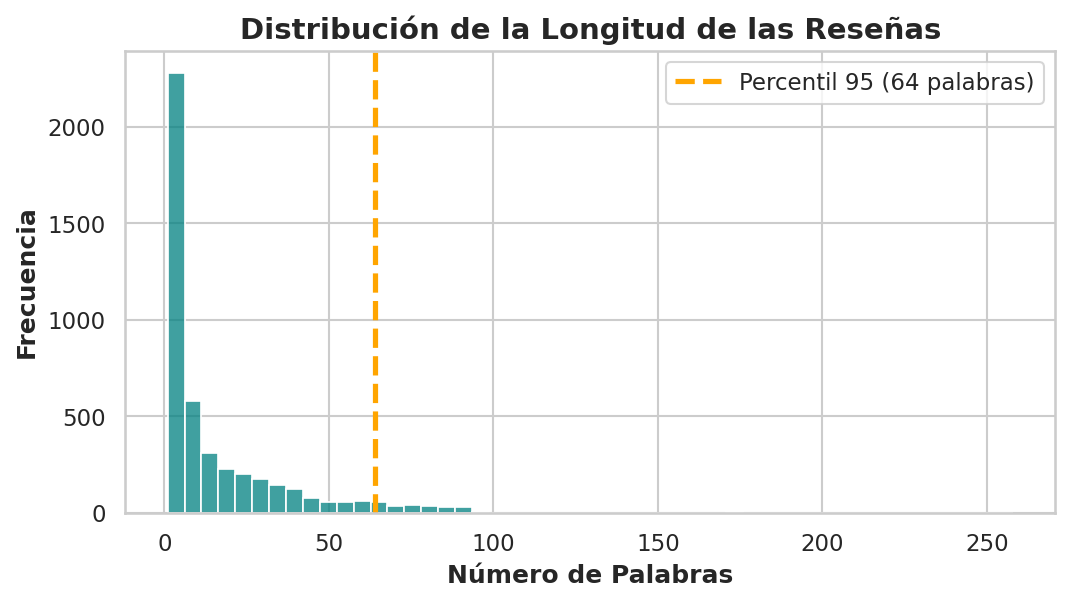

In [3]:
# 1. Carga y limpieza básica
df = load_dataset('datasets/cps/reviews_limpias_2022.csv')
# Nos quedamos con las reseñas que tienen texto válido
df = df.dropna(subset=['clean_reviews']).reset_index(drop=True)

print(f"Total de reseñas: {len(df)}")

# 2. Análisis de Desbalanceo
distribucion = df['sentiment'].value_counts(normalize=True) * 100
print("\nDistribución de Clases:")
for clase, pct in distribucion.items():
    print(f" - {clase.capitalize()}: {pct:.1f}%")

# 3. Análisis de Longitud (Decisión de MAX_LEN)
# Calculamos cuántas palabras tiene cada reseña
df['num_palabras'] = df['clean_reviews'].apply(lambda x: len(str(x).split()))

p95 = int(df['num_palabras'].quantile(0.95))
p99 = int(df['num_palabras'].quantile(0.99))

plt.figure(figsize=(8, 4))
sns.histplot(df['num_palabras'], bins=50, color='teal')
plt.axvline(p95, color='orange', linestyle='--', label=f'Percentil 95 ({p95} palabras)')
plt.title("Distribución de la Longitud de las Reseñas")
plt.xlabel("Número de Palabras")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

Vistazo rápido del dataset:

In [37]:
df

,reviews,stars,rating,sentiment,class,clean_reviews,num_palabras
0,Super confiable...cuando tuve problemas con la...,Calificación: 5 de cinco estrellas,5,positivo,2,super confiable...cuando tuve problemas con la...,65
1,"Tiene un buen diseño, y te aseguras de no entr...",Calificación: 5 de cinco estrellas,5,positivo,2,"tiene un buen diseño, y te aseguras de no entr...",83
2,En mí caso la forma más cómoda de realizar com...,Calificación: 5 de cinco estrellas,5,positivo,2,en mí caso la forma más cómoda de realizar com...,82
3,"Facilita muchas cosas: podes ver precios, moda...",Calificación: 4 de cinco estrellas,4,positivo,2,"facilita muchas cosas: podes ver precios, moda...",82
4,Funciona correctamente. Una sugerencia: en cie...,Calificación: 5 de cinco estrellas,5,positivo,2,funcióna correctamente. una sugerencia: en cie...,63
...,...,...,...,...,...,...,...
4530,Nunca tuve un problema con esta aplicación per...,Calificación: 1 de cinco estrellas,1,negativo,0,nunca tuve un problema con esta aplicación per...,32
4531,Pésima tarjeta no puedo hacer transferencia an...,Calificación: 1 de cinco estrellas,1,negativo,0,pésima tarjeta no puedo hacer transferencia an...,19
4532,"La verdad que me encantaba la aplicación, pero...",Calificación: 2 de cinco estrellas,2,negativo,0,"la verdad que me encantaba la aplicación, pero...",47
4533,Hace una semana q esta caída la cuenta...y muc...,Calificación: 1 de cinco estrellas,1,negativo,0,hace una semana q esta caída la cuenta...y muc...,15


### Decisiones de Ingeniería:


1. **Desbalance Crítico:** La clase "Neutral" representa solo el `~6%` de los datos. Si no intervenimos, la red ignorará esta clase para maximizar su *Accuracy* global. Usamos `class_weight` durante el entrenamiento.
2. **Longitud Máxima (`MAX_LEN`):** El percentil 95 nos indica que el 95% de las reseñas tienen 64 palabras o menos. Fijamos `MAX_LEN = 64`.

*Trade-off de Memoria:* ¿Por qué no usar la longitud máxima absoluta (ej. 250 palabras)? Porque los tensores en memoria se asignan por el tamaño máximo del *batch*. Si usamos 250, la red procesará matrices gigantescas llenas de ceros (*padding*). Truncar el 5% de las reseñas más largas a 64 palabras es un sacrificio aceptable para acelerar el entrenamiento y reducir el consumo de VRAM.

In [4]:
# Preparación de los datos
X = df['clean_reviews'].values

label_enc = LabelEncoder()
y = label_enc.fit_transform(df['sentiment'])
clases_nombres = label_enc.classes_

# División Estratificada (Vital para mantener el 6% de neutrales en todos los sets)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)

# Cálculo de pesos para balancear las clases
pesos = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
pesos_clases = dict(enumerate(pesos))
print(f"Pesos asignados: {pesos_clases}")

Pesos asignados: {0: np.float64(0.6384015594541911), 1: np.float64(5.598290598290598), 2: np.float64(0.7968369829683698)}


## 3. El Pipeline Moderno (*End-to-End*)



> **⚠️ ERROR TÍPICO (Training-Serving Skew):**
> Históricamente, se usaba un `Tokenizer` de Python para convertir texto a números, se guardaba como un archivo `.pkl`, y el modelo se entrenaba con números. En producción, si el archivo `.pkl` se perdía o desincronizaba, el modelo recibía números equivocados y predecía basura.

**Solución Profesional:** Usar `keras.layers.TextVectorization`. Esta capa vive **dentro del grafo de la red neuronal**. El modelo exportado aceptará *strings* de texto crudo directamente.

In [5]:
VOCAB_SIZE = 10000
MAX_LEN = 64

# 1. Definimos la capa de vectorización
vectorizador = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN
)

# 2. "Adaptamos" la capa al vocabulario de entrenamiento
# Esto crea el diccionario interno (palabra -> número)
print("Construyendo vocabulario...")
vectorizador.adapt(X_train)

# Veamos un ejemplo de cómo funciona internamente
texto_ejemplo = "la app funciona muy mal"
vectorizado = vectorizador(np.array([texto_ejemplo]))
print(f"Texto: '{texto_ejemplo}'")
print(f"Vectorizado: {vectorizado.numpy()[0][:10]}... (rellenado con ceros)")

Construyendo vocabulario...
Texto: 'la app funciona muy mal'
Vectorizado: [ 3 16  1  9 95  0  0  0  0  0]... (rellenado con ceros)


## 4. El "Zoológico" de las Secuencias: Comparativa Práctica


Una vez que tenemos números, ¿qué capa usamos para procesar la secuencia?
En la industria, elegimos entre tres grandes familias para procesar secuencias.


| Arquitectura | Cómo funciona | Ventajas | Desventajas | Caso de Uso Ideal |
| :--- | :--- | :--- | :--- | :--- |
| **Conv1D** | Desliza un filtro sobre la secuencia (ej. lee de a 3 palabras). | Rapidísima. Muy pocos parámetros. | No tiene "memoria". Falla si el contexto está muy separado. | Análisis de logs, detección de n-gramas simples. |
| **LSTM** | Tiene una "cinta transportadora" (*Cell State*) y compuertas que deciden qué recordar y qué olvidar paso a paso. | Excelente memoria a largo plazo. Evita el *Vanishing Gradient*. | Lenta de entrenar. Muchos parámetros. No paralelizable. | NLP complejo, traducción, series temporales largas. |
| **GRU** | Versión simplificada de LSTM (fusiona compuertas). | `~30%` menos parámetros que LSTM. Casi el mismo rendimiento. | Ligeramente inferior a LSTM en secuencias extremadamente largas. | Hardware embebido, prototipado rápido. |


En lugar de solo teorizar (aparte de la tabla), construimos una versión ligera de cada una para compararlas empíricamente. Se intenta equiparar las arquitecturas en cantidad de parámetros, las 3 se entrenan por 3 época con la misma configuración:

In [16]:
import time

def evaluar_arquitectura(tipo_capa, nombre):
    inputs = keras.Input(shape=(MAX_LEN,))
    x = keras.layers.Embedding(VOCAB_SIZE, 32, mask_zero=(tipo_capa != keras.layers.Conv1D))(inputs)

    if tipo_capa == keras.layers.Conv1D:
        x = tipo_capa(32, kernel_size=3, activation='relu')(x)
        x = keras.layers.GlobalMaxPooling1D()(x)
    else:
        x = tipo_capa(32)(x)

    outputs = keras.layers.Dense(3, activation='softmax')(x)
    modelo = keras.Model(inputs, outputs)
    modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Preparamos datos vectorizados para la prueba rápida
    X_train_vec = vectorizador(X_train)
    X_val_vec = vectorizador(X_val)

    inicio = time.time()
    hist = modelo.fit(X_train_vec, y_train, validation_data=(X_val_vec, y_val), epochs=3, batch_size=128, verbose=0)
    tiempo = time.time() - inicio

    return modelo.count_params(), tiempo, hist.history['val_accuracy'][-1]

print(f"{'Arquitectura':<10} | {'Parámetros':<10} | {'Tiempo (3 ep)':<15} | {'Val Accuracy'}")
print("-" * 55)

# Ejecutamos la comparativa
params_c, t_c, acc_c = evaluar_arquitectura(keras.layers.Conv1D, "Conv1D")
print(f"{'Conv1D':<10} | {params_c:<10,} | {t_c:<15.2f} | {acc_c:.4f}")

params_g, t_g, acc_g = evaluar_arquitectura(keras.layers.GRU, "GRU")
print(f"{'GRU':<10} | {params_g:<10,} | {t_g:<15.2f} | {acc_g:.4f}")

params_l, t_l, acc_l = evaluar_arquitectura(keras.layers.LSTM, "LSTM")
print(f"{'LSTM':<10} | {params_l:<10,} | {t_l:<15.2f} | {acc_l:.4f}")

Arquitectura | Parámetros | Tiempo (3 ep)   | Val Accuracy
-------------------------------------------------------
Conv1D     | 323,203    | 4.09            | 0.7945
GRU        | 326,435    | 10.29           | 0.8152
LSTM       | 328,419    | 11.17           | 0.8446


**Criterio de Ingeniería (Análisis de Resultados):**   
Observar los números empíricos.  
- **Conv1D** es casi 3 veces más rápida que LSTM (`~4 s` vs `~11 s`) porque procesa los n-gramas en paralelo, pero paga el precio perdiendo un `5%` de *Accuracy*. Al no tener memoria, falla en reseñas largas.
- **GRU** y **LSTM** logran un rendimiento superior (`>81-84%`). Aunque GRU es ligeramente más rápida, para análisis de sentimiento donde el sarcasmo o una negación al principio de la frase cambia todo el sentido, la memoria a largo plazo de la **LSTM** demuestra ser la ganadora absoluta para este dataset.

## 5. Arquitectura y Entrenamiento (usamos: BiLSTM)



Construimos el modelo *End-to-End*. Utilizamos además una capa `Bidirectional`, permitiéndole a la LSTM "leer" en ambos sentidos.

> **💡 PRO-TIP DE INDUSTRIA (`mask_zero=True`):**
> Nuestra secuencia tiene longitud 64, pero si un comentario tiene 3 palabras, las otras 61 son ceros (*padding*). Si no le decimos nada, la LSTM procesará esos 61 ceros, desperdiciando más del 90% del tiempo de cómputo. Al poner `mask_zero=True` en la capa `Embedding`, la red ignora matemáticamente los ceros, acelerando el entrenamiento masivamente. *Abajo se explica con más detalle...*

In [6]:
# --- 1. ENTRADA DE TEXTO CRUDO ---
# Nota: dtype=tf.string permite que el modelo reciba texto directamente
inputs = keras.Input(shape=(1,), dtype=tf.string, name="texto_crudo")

# --- 2. PREPROCESAMIENTO INTEGRADO ---
x = vectorizador(inputs)

# --- 3. EMBEDDING (El Mapa Semántico) ---
# Transforma cada índice entero en un vector denso de 64 dimensiones.
# mask_zero=True es vital para la eficiencia.
x = keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=64,
    mask_zero=True,
    name="mapa_semantico"
)(x)

# --- 4. PROCESAMIENTO SECUENCIAL (BiLSTM) ---
# Bidirectional lee la frase de izquierda a derecha Y de derecha a izquierda.
# Esto es crucial para entender contextos como: "No es buena, es excelente".
x = keras.layers.Bidirectional(keras.layers.LSTM(64))(x)
x = keras.layers.Dropout(0.4)(x)

# --- 5. CLASIFICACIÓN ---
x = keras.layers.Dense(32, activation='relu')(x)
outputs = keras.layers.Dense(3, activation='softmax', name="prediccion")(x)

# Ensamblaje
modelo_nlp = keras.Model(inputs, outputs, name="Analizador_Sentimiento_End2End")

modelo_nlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_nlp.summary()

Model: "Analizador_Sentimiento_End2End"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ texto_crudo         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 64)        │          0 │ texto_crudo[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mapa_semantico      │ (None, 64, 64)    │    640,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 64)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128)       │     66,048 │ mapa_semantico[0… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      4,128 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediccion (Dense)  │ (None, 3)         │         99 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 710,275 (2.71 MB)

 Trainable params: 710,275 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

### Lectura de Ingeniería: Entendiendo el Summary

1. **La Capa Oculta `NotEqual` (el poder del Masking):** Al activar `mask_zero=True` en el Embedding, Keras inserta automáticamente una operación lógica (`NotEqual`) que crea una máscara booleana. Esta máscara viaja junto con los datos y le dice a la LSTM: *"Si el valor es 0, apaga tus cálculos y simplemente copia el estado anterior"*. Esto ahorra ciclos de reloj masivos.
2. **El Peso del Vocabulario:** Observar los parámetros. De los `~710.000` parámetros totales, **`640.000` pertenecen exclusivamente a la capa Embedding** (`10.000` palabras $\times$ `64` dimensiones). La red gasta el 90% de su capacidad solo en aprender el idioma. *Por esto en la industria rara vez entrenamos Embeddings desde cero; usamos modelos pre-entrenados como Word2Vec o FastText.*
3. **¿Por qué Bidirectional?** Una LSTM normal lee: *"La app no es buena, es terrible"*. Cuando llega a "terrible", ya casi olvidó el "no". Una `Bidirectional` clona la LSTM: una lee de izquierda a derecha, y la otra de derecha a izquierda. Al concatenar ambos resultados, la red tiene el contexto completo del pasado y el futuro de cada palabra.

### Entrenamiento


In [7]:
callbacks =[
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

print("Entrenando modelo BiLSTM End-to-End...")
historia = modelo_nlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    class_weight=pesos_clases, # Aplicamos los pesos para salvar a la clase Neutral
    callbacks=callbacks,
    verbose=1
)

Entrenando modelo BiLSTM End-to-End...
Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 300ms/step - accuracy: 0.7047 - loss: 1.0738 - val_accuracy: 0.7288 - val_loss: 0.9931 - learning_rate: 0.0010
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 208ms/step - accuracy: 0.7762 - loss: 0.8456 - val_accuracy: 0.7703 - val_loss: 0.6828 - learning_rate: 0.0010
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 279ms/step - accuracy: 0.8421 - loss: 0.6299 - val_accuracy: 0.7962 - val_loss: 0.5637 - learning_rate: 0.0010
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.8928 - loss: 0.4603 - val_accuracy: 0.8325 - val_loss: 0.5062 - learning_rate: 0.0010
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 471ms/step - accuracy: 0.9356 - loss: 0.3487 - val_accuracy: 0.8411 - val_loss: 0.5037 - learning_rate: 0.0010
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 333ms/step - accuracy: 0.9487 - loss: 0.2919 - val_accuracy: 0.8290 - val_loss: 0.5194 - learning_rate: 0.0010
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 426m

## 6. Abriendo la Caja Negra: Visualizando los Embeddings

La capa `Embedding` no es solo una tabla de búsqueda; es un espacio geométrico donde la red agrupó las palabras según su semántica. Vamos a extraer esta matriz de `640.000` pesos y proyectarla a 2D usando UMAP para ver si la red realmente "entendió" el español `+"argentino"`.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


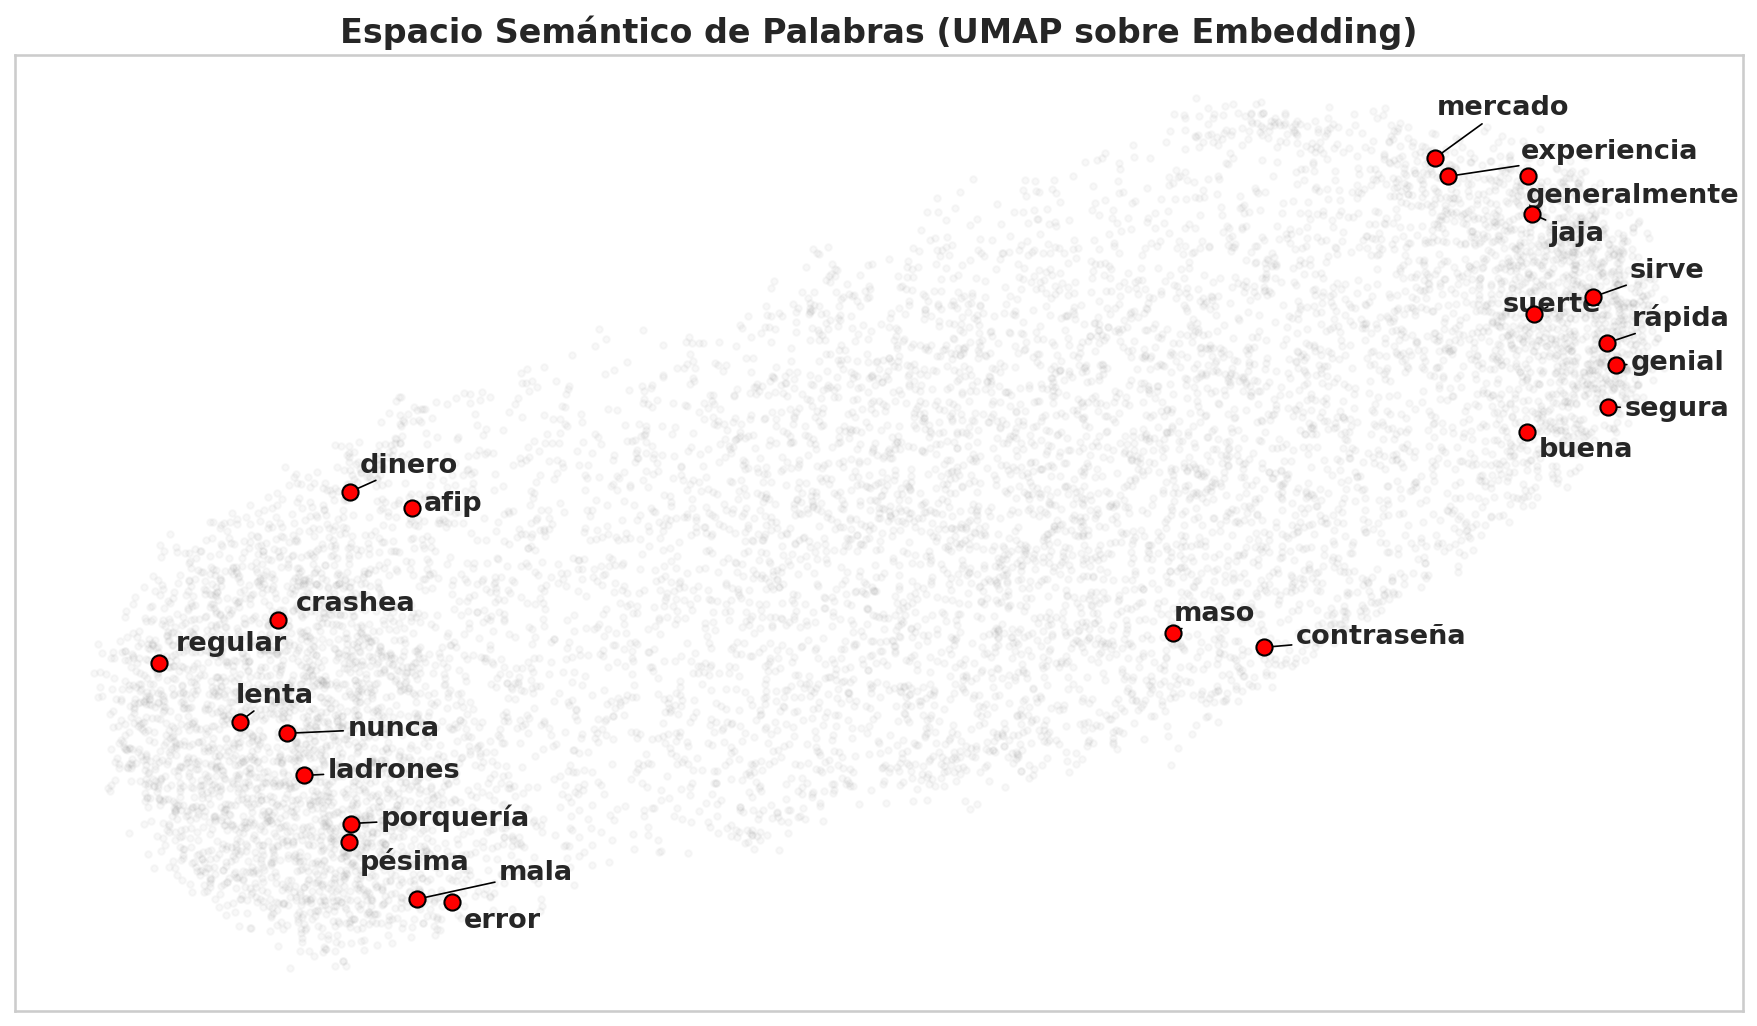

In [34]:
import umap
from adjustText import adjust_text # Librería mas pro para evitar superposición de textos

# 1. Extraemos el vocabulario y los pesos
vocabulario = vectorizador.get_vocabulary()
pesos_embedding = modelo_nlp.get_layer("mapa_semantico").get_weights()[0]

# Ignoramos los primeros 2 tokens (el padding '0' y el OOV '[UNK]')
palabras = vocabulario[2:]
vectores = pesos_embedding[2:]

# 2. Reducimos de 64D a 2D con UMAP
reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
vectores_2d = reducer.fit_transform(vectores)

# 3. Visualizamos un subconjunto de palabras clave
palabras_clave = ["sirve", "buena", "genial", "mala", "pésima", "segura",
                  "error", "crashea", "rápida", "lenta", "maso", "porquería",
                  "lentísima", "suerte", "ladrones", "afip", "mercado", "regular",
                  "experiencia", "nunca", "generalmente", "contraseña", "jaja", "dinero"]

plt.figure(figsize=(12, 7))
# Dibujamos el fondo de palabras en gris claro
plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1], alpha=0.05, color='gray', s=10)

textos_a_ajustar = []

for palabra in palabras_clave:
    if palabra in palabras:
        idx = palabras.index(palabra)
        x, y = vectores_2d[idx]
        # Dibujamos el punto rojo
        plt.scatter(x, y, color='red', s=60, edgecolors='black', zorder=5)
        # Guardamos el texto en una lista en lugar de dibujarlo directamente
        textos_a_ajustar.append(plt.text(x, y, palabra, fontsize=13, fontweight='bold'))

# 4. Magia de Visualización: Ajustamos los textos para que no se superpongan
# Dibuja pequeñas flechas si tiene que mover mucho el texto
# Instalé una librería arriba para poder organizar bien esto...
adjust_text(textos_a_ajustar, arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

plt.title("Espacio Semántico de Palabras (UMAP sobre Embedding)", fontsize=16)
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

**Diagnóstico Visual**:
¡Observar la topología del lenguaje! La red creó un espectro semántico perfecto. En un extremo agrupó los conceptos positivos ("excelente", "genial", "rápida"). En el extremo opuesto, agrupó las quejas ("pésima", "crashea", "error"). Y justo en el medio del espacio, ubicó palabras neutrales o ambiguas como "maso". La red neuronal aprendió a leer español simplemente intentando predecir estrellas.

Si todas las palabras quedaran mezcladas aleatoriamente, significa que la red no tuvo suficientes datos o épocas para aprender el idioma.

## 7. Evaluación y Calibración de Confianza


Evaluamos el modelo en el Test Set.



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    negativo       0.91      0.85      0.88       356
     neutral       0.16      0.30      0.21        40
    positivo       0.89      0.86      0.87       285

    accuracy                           0.82       681
   macro avg       0.65      0.67      0.65       681
weighted avg       0.86      0.82      0.84       681



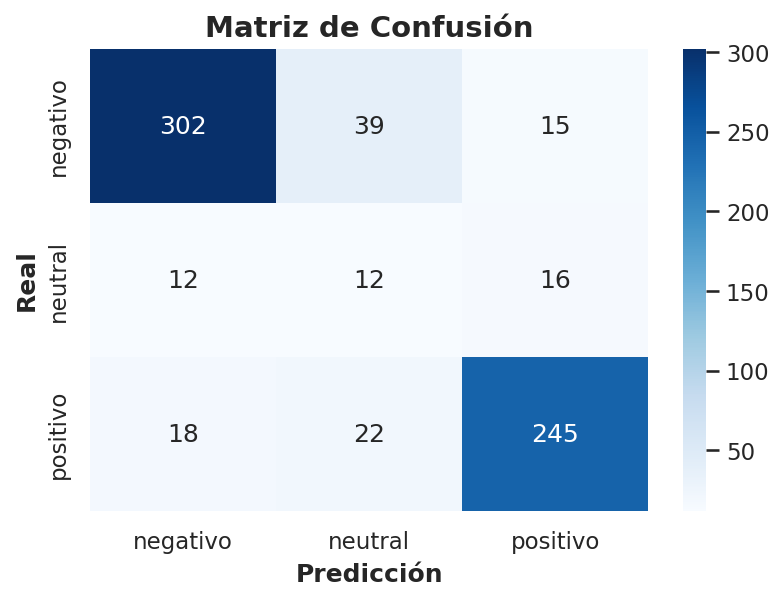

In [12]:
# Predicciones (Probabilidades)
y_pred_probs = modelo_nlp.predict(X_test, verbose=0)
# Clase con mayor probabilidad
y_pred_clases = np.argmax(y_pred_probs, axis=1)

print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred_clases, target_names=clases_nombres))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_clases)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clases_nombres, yticklabels=clases_nombres)
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

### Análisis de la Clase "Neutral"


Observar la matriz de confusión. La clase "Neutral" concentra los mayores errores. ¿Por qué? Porque semánticamente es la más ambigua. Un usuario que pone 3 estrellas puede escribir *"La app es buena pero le faltan funciones"* (mezcla de positivo y negativo). La red sufre para clasificar esta ambigüedad.
Además, en la clase con menos muestras.

### Calibración de Confianza (El modelo dice "No sé")



En producción, un sistema no necesita clasificar el 100% de los datos automáticamente. Si el modelo está inseguro, es mejor derivar la reseña a un humano. Vamos a analizar la **Confianza** (la probabilidad máxima que emitió la red).



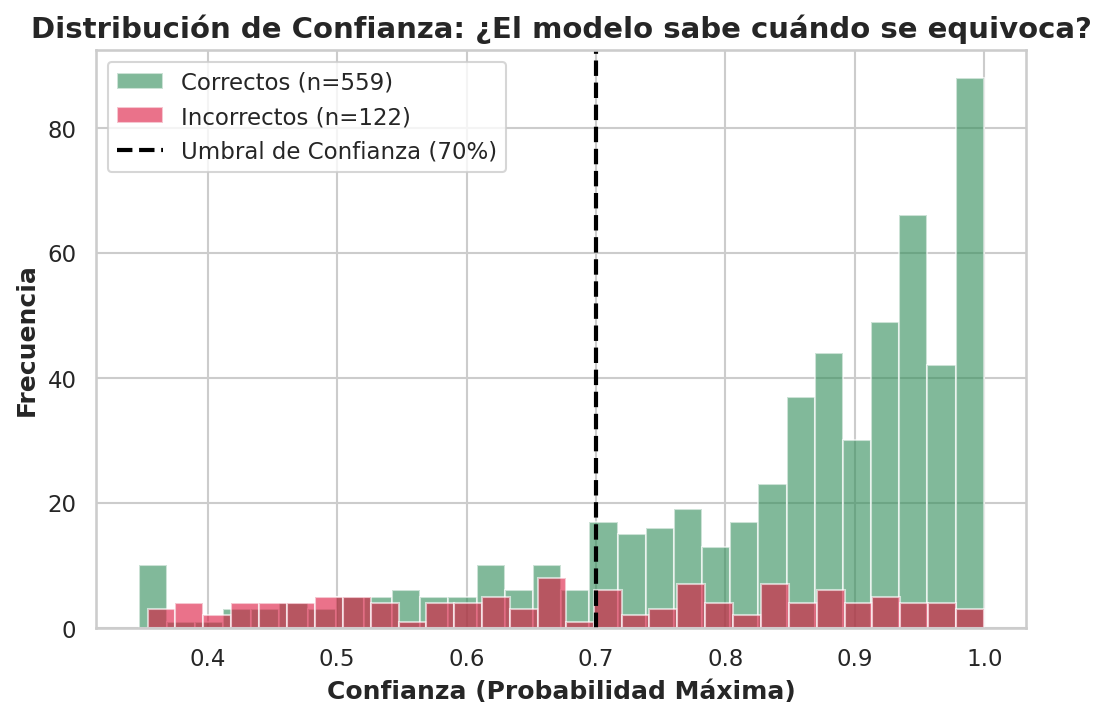

In [19]:
# Extraemos la confianza de cada predicción
confianza_maxima = np.max(y_pred_probs, axis=1)
es_correcto = (y_pred_clases == y_test)

plt.figure(figsize=(8, 5))
plt.hist(confianza_maxima[es_correcto], bins=30, alpha=0.6, color='seagreen', label=f'Correctos (n={sum(es_correcto)})')
plt.hist(confianza_maxima[~es_correcto], bins=30, alpha=0.6, color='crimson', label=f'Incorrectos (n={sum(~es_correcto)})')
plt.axvline(0.7, color='black', linestyle='--', linewidth=2, label='Umbral de Confianza (70%)')
plt.title("Distribución de Confianza: ¿El modelo sabe cuándo se equivoca?")
plt.xlabel("Confianza (Probabilidad Máxima)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

**Criterio de Negocio:** Observar la gráfica. Lo ideal sería que la mayoría de los errores (rojo) ocurran cuando la confianza del modelo es baja (menor a `0,70` por ejemplo). En este caso, **no ocurre de forma perfecta**. Los errores se distribuyen por todo el rango de confianza. Entrenamos con pocos datos y un embedding "grande" desde cero, lo que hace que la red sea "sobreconfiada" incluso cuando se equivoca. Así y todo, para valores menores a `0,7`, las distribuciones se mezclan casi totalmente así que amerita la siguiente recomendación:

> En un modelo maduro donde sí podemos valernos de la confianza como señal, implementaríamos una regla en nuestro servidor: *"Si la confianza es `< 70%`, enviar a revisión manual"*. Lograríamos automatizar la gran mayoría del trabajo manteniendo una precisión casi perfecta en lo que sí automatizamos.

## 8. Abstracción: De NLP a Series Temporales (IoT / Finanzas)


Es un error común pensar que las LSTMs son exclusivas para texto. Para una red neuronal, una palabra es solo un vector de números (gracias al `Embedding`).

Si trabajamos en una planta industrial y tenemos un sensor de temperatura que emite una lectura cada hora durante 30 días, tenemos una secuencia de 720 pasos de tiempo.
La forma del tensor de entrada sería `(batch_size, 720, 1)`.

**¿Cómo adaptamos nuestra arquitectura?**  
¡Es exactamente la misma! Simplemente eliminamos la capa `TextVectorization` y la capa `Embedding`. Conectamos los datos numéricos crudos directamente a la capa `LSTM`. La matemática de la memoria a corto y largo plazo funcionará idénticamente para predecir si el motor va a fallar o no.

## 9. El Estado del Arte: Transformers


Las LSTMs dominaron el mundo de las secuencias hasta 2017. Sin embargo, tienen un límite físico infranqueable: **No se pueden paralelizar**.
Para que una LSTM procese la palabra 50 de un texto, debe haber terminado de procesar las 49 palabras anteriores secuencialmente. Esto hace que entrenar LSTMs en datasets gigantescos sea extremadamente lento, desaprovechando el poder paralelo de las GPUs modernas.
Además, incluso con compuertas, si un texto tiene 500 palabras, el vector final pierde resolución sobre las primeras palabras. Es decir, una especie de "amnesia a larga distancia".



La solución llegó en 2017 con el paper *"Attention is All You Need"*. Propuso algo radical: ¿Qué pasaría si en lugar de leer secuencialmente, la red mira **todas las palabras al mismo tiempo** y calcula matemáticamente qué palabras deben "prestarse atención" entre sí? (Ej. En "El banco de la plaza", "banco" debe prestar atención a "plaza" para saber que no es una institución financiera).

Esta eliminación de la recurrencia dio nacimiento a los **Transformers** (BERT, GPT), permitiendo entrenar modelos con billones de parámetros en paralelo.

## Conexiones y Próximos Pasos



Construimos un pipeline de NLP de nivel de producción, resistente al *Training-Serving Skew* y con calibración de confianza.

- ➡️ **Siguiente:** En el  notebook [Atención y Transformers](11_atencion_y_transformers_intro.ipynb), dejamos atrás la recurrencia y construimos el mecanismo que revolucionó la Inteligencia Artificial moderna.
- 🔄 **Relacionado:** Si se quiere ver cómo aplicar LSTMs y otras concurrentes a datos puramente numéricos, revisar próximamente los casos de estudio...

## Referencias


### Artículos Fundacionales

1. **Hochreiter, S., & Schmidhuber, J. (1997)**. *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780.  
   [[PDF]](https://www.bioinf.jku.at/publications/older/2604.pdf)  
   (Paper original de LSTM).

2. **Cho, K., et al. (2014)**. *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation*. EMNLP.  
   [[arXiv]](https://arxiv.org/abs/1406.1078)  
   (Paper original de GRU).

3. **Vaswani, A., et al. (2017)**. *Attention Is All You Need*. NeurIPS.  
   [[arXiv]](https://arxiv.org/abs/1706.03762)  
   (Paper que introdujo los Transformers – lectura obligatoria para entender el futuro y nuestro presente).

### Recursos Prácticos y Oficiales

- **Chollet, F. (2021)**. *Deep Learning with Python, Second Edition* (Capítulo sobre secuencias y NLP). Manning.
- **Keras Team**. [Guía Oficial de Keras: *Text Classification from Scratch*](https://keras.io/examples/nlp/text_classification_from_scratch/).  
  (Excelente guía oficial que usa `TextVectorization`).


---


## Entorno de Ejecución


In [38]:
from utils.environment import environment_table
environment_table(include_all=True)

Package,Version
Python,3.12.13
Platform,Linux-6.6.122+-x86_64-with-glibc2.35
Cython,3.0.12
IPython,7.34.0
OpenSSL,24.2.1
PIL,11.3.0
adjustText,1.3.0
anywidget,0.9.21
argparse,1.1
astunparse,1.6.3
